In [1]:
import rootutils
from pathlib import Path
from functools import partial

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split

rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)

from src.models.lightning_module import PreTrainLightning
from src.models.MAE.model import MaskedAutoencoderViT
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from src.data.components.dataset import Spatial2DDataset

# Keep the tutorial deterministic and lightweight.
seed_everything(12345, workers=True)
torch.set_float32_matmul_precision("medium")

/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 12345


In [2]:
# Load the tiny dataset created in 1.setup.ipynb and make a tiny split.
tutorial_dir = Path.cwd() / "tutorials" / "tutorial_spatial2D"
if not (tutorial_dir / "train_data.npz").exists():
    tutorial_dir = Path.cwd()

dataset = Spatial2DDataset(data_dir=str(tutorial_dir), prefix="train")
sample = dataset[0]
img_size = sample.shape[-1]
patch_size = 16
num_classes = sample.shape[0]

if img_size % patch_size != 0:
    raise ValueError(f"img_size={img_size} must be divisible by patch_size={patch_size}.")

train_size = max(1, int(0.8 * len(dataset)))
val_size = max(1, len(dataset) - train_size)
if train_size + val_size > len(dataset):
    train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(12345),
)

train_loader = DataLoader(train_dataset, batch_size=min(2, len(train_dataset)), shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=min(2, len(val_dataset)), shuffle=False)

print(f"dataset path: {tutorial_dir / 'train_data.npz'}")
print(f"dataset size: {len(dataset)}")
print(f"sample shape: {tuple(sample.shape)}")
print(f"train size: {len(train_dataset)} | val size: {len(val_dataset)}")
print(f"img_size: {img_size} | patch_size: {patch_size} | num_classes: {num_classes}")

dataset path: /home/kangyu/project/viaABC/tutorials/tutorial_spatial2D/train_data.npz
dataset size: 3
sample shape: (6, 1200, 1200)
train size: 2 | val size: 1
img_size: 1200 | patch_size: 16 | num_classes: 6


per-class pixel counts: [279486, 94708, 75302, 990504, 0, 0]


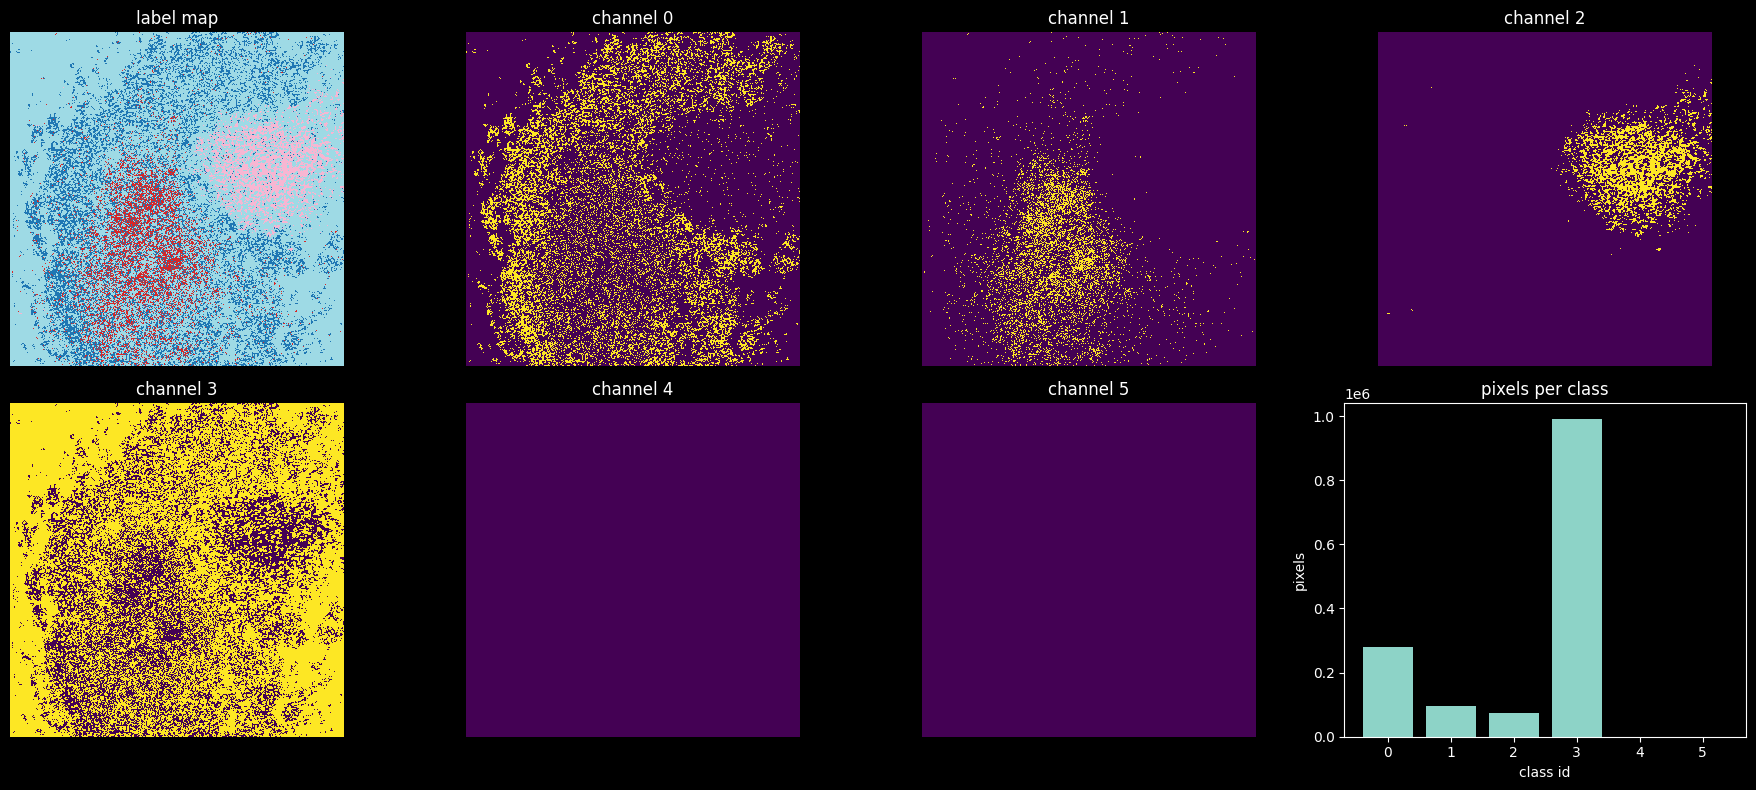

In [3]:
# Spatial2DDataset returns a 6-channel one-hot tensor.
# The argmax view recovers the class map, while each channel shows one class mask.
sample_labels = sample.argmax(dim=0)
class_counts = sample.sum(dim=(1, 2)).to(torch.int64)
print("per-class pixel counts:", class_counts.tolist())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

axes[0].imshow(sample_labels, cmap="tab20", interpolation="nearest")
axes[0].set_title("label map")
axes[0].axis("off")

for class_idx in range(num_classes):
    axes[class_idx + 1].imshow(sample[class_idx], cmap="viridis", interpolation="nearest")
    axes[class_idx + 1].set_title(f"channel {class_idx}")
    axes[class_idx + 1].axis("off")

axes[-1].bar(range(num_classes), class_counts.tolist())
axes[-1].set_title("pixels per class")
axes[-1].set_xlabel("class id")
axes[-1].set_ylabel("pixels")

plt.tight_layout()
plt.show()

train batches: 1 | val batches: 1
batch shape: (2, 6, 1200, 1200)


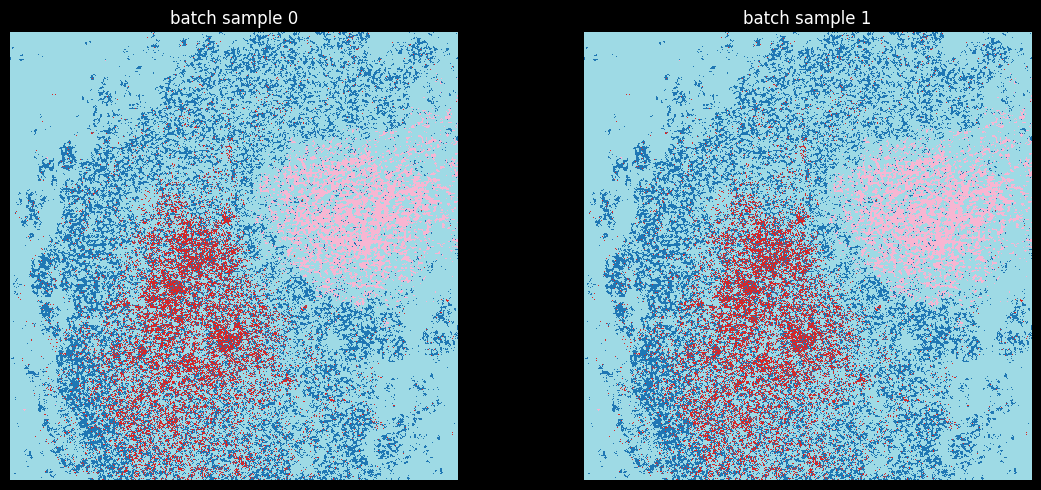

In [4]:
# The dataloader stacks samples into a batch of shape [B, C, H, W].
batch = next(iter(train_loader))
print(f"train batches: {len(train_loader)} | val batches: {len(val_loader)}")
print(f"batch shape: {tuple(batch.shape)}")

num_examples = min(2, batch.shape[0])
fig, axes = plt.subplots(1, num_examples, figsize=(6 * num_examples, 5))
if num_examples == 1:
    axes = [axes]

for i in range(num_examples):
    axes[i].imshow(batch[i].argmax(dim=0), cmap="tab20", interpolation="nearest")
    axes[i].set_title(f"batch sample {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


model type: MaskedAutoencoderViT
total parameters: 2,286,976
num patches: 5625
mask ratio: 0.5
latent shape: (2, 2813, 128)
masked patch fraction: 0.500
recon_loss: 1.8190 | space_loss: 7.9796


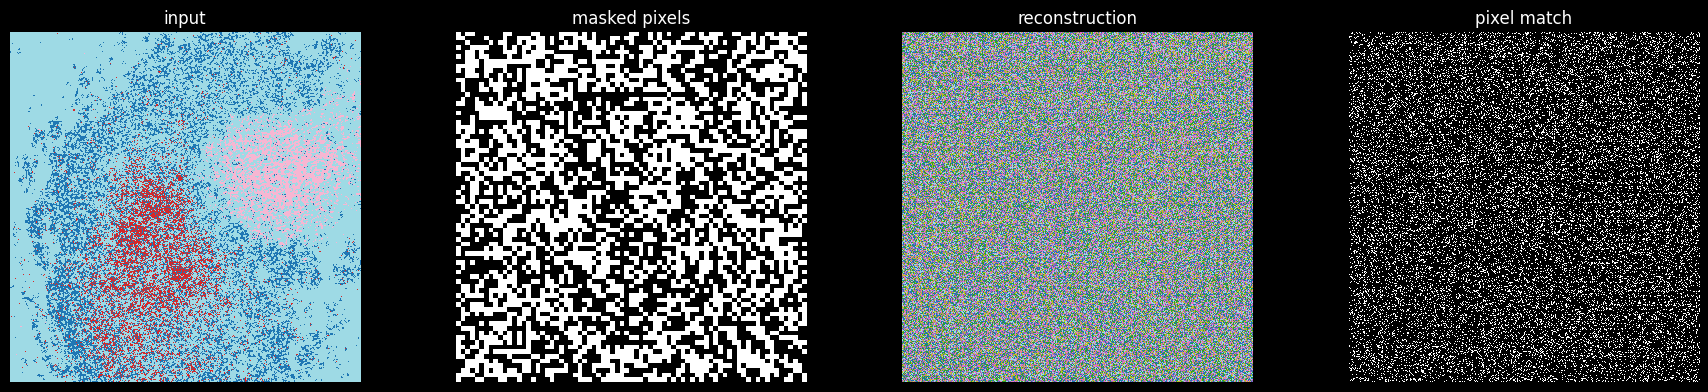

In [5]:
# Build a small MAE that matches the dataset: 6 input channels and square images.
model = MaskedAutoencoderViT(
    img_size=img_size,
    patch_size=patch_size,
    in_chans=num_classes,
    out_chans=num_classes,
    embed_dim=128,
    depth=4,
    num_heads=4,
    decoder_embed_dim=64,
    decoder_depth=2,
    decoder_num_heads=4,
    mask_ratio=0.5,
    kld_weight=0.1,
)

lightning_module = PreTrainLightning(
    net=model,
    optimizer=partial(torch.optim.AdamW, lr=1e-4, betas=(0.9, 0.95), weight_decay=0.05),
    scheduler=None,
    compile=False,
    vae_warmup_steps=100,
    annealing=False,
)

num_params = sum(p.numel() for p in model.parameters())
print(f"model type: {model.__class__.__name__}")
print(f"total parameters: {num_params:,}")
print(f"num patches: {model.patch_embed.num_patches}")
print(f"mask ratio: {model.mask_ratio}")

# Run one forward pass before training so we can see what the untrained model does.
with torch.no_grad():
    latent, mask, ids_restore = model.forward_encoder(batch, model.mask_ratio)
    pred = model.forward_decoder(latent, ids_restore)
    recon_loss = model.forward_recon_loss(batch, pred, mask)
    if model.z_type == "vae":
        mu = model.decoder_embed[1].latent_mean
        logvar = model.decoder_embed[1].latent_logvar
        space_loss = model.forward_space_loss(mu, logvar)
    else:
        space_loss = torch.tensor(0.0)

pred_logits = model.unpatchify(pred)
pred_labels = pred_logits.argmax(dim=1)
pixel_mask = model.unpatchify(mask.unsqueeze(-1).expand(-1, -1, patch_size * patch_size).float()).squeeze(1)

print(f"latent shape: {tuple(latent.shape)}")
print(f"masked patch fraction: {mask.float().mean().item():.3f}")
print(f"recon_loss: {recon_loss.item():.4f} | space_loss: {float(space_loss):.4f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(batch[0].argmax(dim=0), cmap="tab20", interpolation="nearest")
axes[0].set_title("input")
axes[0].axis("off")

axes[1].imshow(pixel_mask[0].cpu(), cmap="gray", interpolation="nearest")
axes[1].set_title("masked pixels")
axes[1].axis("off")

axes[2].imshow(pred_labels[0].cpu(), cmap="tab20", interpolation="nearest")
axes[2].set_title("reconstruction")
axes[2].axis("off")

axes[3].imshow((batch[0].argmax(dim=0) == pred_labels[0]).cpu(), cmap="gray", interpolation="nearest")
axes[3].set_title("pixel match")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Finally, run a tiny Lightning loop to confirm the full training path works.
# We only use one train batch and one val batch per epoch to keep the tutorial fast.
trainer = Trainer(
    max_epochs=2,
    accelerator="auto",
    devices=1,
    callbacks=[
        ModelCheckpoint(monitor="val/loss", mode="min"),
        LearningRateMonitor(logging_interval="epoch"),
        EarlyStopping(monitor="val/loss", mode="min", patience=3),
    ],
    log_every_n_steps=1,
    limit_train_batches=1,
    limit_val_batches=1,
    num_sanity_val_steps=0,
)

print("Starting a tiny Lightning sanity check...")
print("Watch the logged values: train/recon_loss, train/space_loss, and val/loss.")

trainer.fit(lightning_module, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
`Trainer(limit_train_batches=1)` was configured so 1 batch per epoch will be used.
`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.


Starting a tiny Lightning sanity check...
Watch the logged values: train/recon_loss, train/space_loss, and val/loss.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                 | Params | Mode 
-------------------------------------------------------
0 | model | MaskedAutoencoderViT | 2.3 M  | train
-------------------------------------------------------
1.2 M     Trainable params
1.1 M     Non-trainable params
2.3 M     Total params
9.148     Total estimated model params size (MB)
146       Modules in train mode
0         Modules in eval mode
/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing

Epoch 1: 100%|██████████| 1/1 [00:00<00:00,  3.25it/s, v_num=0]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 1/1 [00:00<00:00,  2.69it/s, v_num=0]
